1. Compute TE between units for all ripples, see if some pairs are significant -> interaction between regions?
2. Compare ripples before vs after learning to see if increase

Future goals, around ripples:
1. Show if TE( HPC -> NR -> PFC ) > TE( HPC -> PFC ) in [-100,300] ms
2. Show if gain in predicting next PFC state considering HPC history vs HPC+NR history changes over time

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import itertools
import hoi

/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/utils/logging.py:49: SyntaxWarning: invalid escape sequence '\*'
  regexp = "\*.*?\*"
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/metrics/infotopo.py:45: SyntaxWarning: invalid escape sequence '\s'
  """Topological Information.
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/metrics/rsi.py:14: SyntaxWarning: invalid escape sequence '\e'
  """Redundancy-Synergy Index (RSI).


In [2]:
# parameters
regs = ['hpc','nr','pfc']
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_units.batch'
session = fma.data.readBatchFile(batch_file)[0][19]
print(f'session: {session}')
reg_pair_idx = list(itertools.permutations(range(len(regs)),2))
reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]

session: /mnt/hubel-data-140/karadoc/Rat004_20240306/Rat004_20240306.xml


In [3]:
# load data
R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}
rip_time = R.eventInfo('ripples')[:,2]
spikes = R.spikes()

1. TE

In [22]:
# (n_ripples, n_t, n_units)
n_rip = 10
rip_peth, t, _ = fma.analysis.PETH(spikes[:,0],rip_time[:n_rip],groups=spikes[:,1],limits=[-0.1,0.3],n_bins=101,fast=True) # MAYBE NO OVERLAP BINS!! for t independence

In [14]:
rip_peth.reshape(rip_peth.shape[1],rip_peth.shape[2],rip_peth.shape[0]).shape

(101, 306, 10)

In [15]:
model = hoi.metrics.TransferEntropy(rip_peth.reshape(rip_peth.shape[1],rip_peth.shape[2],rip_peth.shape[0]), )
fit = model.fit(method="binning", matrix=True) # EXPLORE FOR DIFFERENT TAUS MAYBE

Get list of multiplets


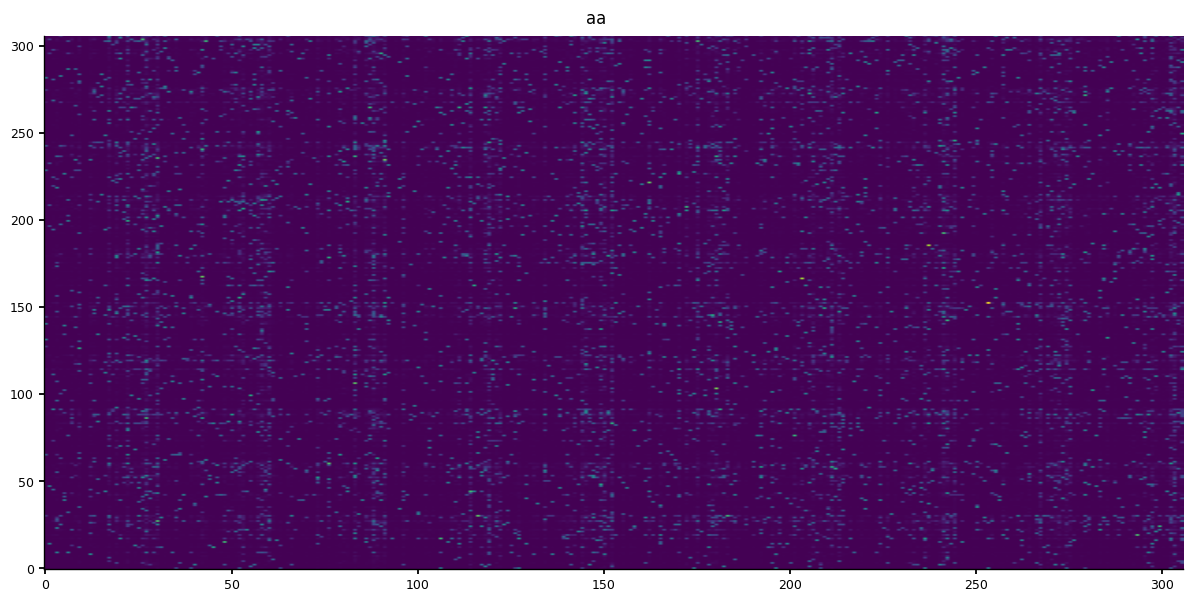

In [21]:
# idee: confronta matrici di ripples primas vs dopo learning
# fai misura di distanza tra diverse ripple matrices cosi effetto over time
# n di significant neuron pairs
# fai TE frites con ext variable pre- post task, conn_fit ??
fma.plotting.makeFigure('aa',size=[30,15])
fma.plotting.plotColorMap(fit.mean(axis=-1));

1. Try Oinfo around ripples

How do I concatenate data from multiple ripples? I can ALSO GIVE THE SAME SHAPE AS TE hoi
NOte that Oinfo is static (no time delay)

In [4]:
# (n_ripples, n_t, n_units)
rip_peth, t, _ = fma.analysis.PETH(spikes[:,0],rip_time[:400],groups=spikes[:,1],limits=[-0.1,0.3],n_bins=51,fast=True)

In [5]:
model = hoi.metrics.Oinfo(rip_peth.reshape(-1,rip_peth.shape[-1]).astype(float))
fit = model.fit(method="binning", minsize=3, maxsize=3)

    Copnorm and demean the data
Get list of multiplets


In [6]:
best = hoi.utils.get_nbest_mult(fit, model, n_best=20)
multiplets = np.stack(best["multiplet"].to_numpy())
reg_mult = np.full(multiplets.shape,'aaa')
for i in range(len(multiplets)):
    for j in range(multiplets.shape[1]):
        for r in unit_range:
            if unit_range[r][0] <= multiplets[i,j] <= unit_range[r][1]:
                reg_mult[i,j] = r
best['region'] = [r for r in reg_mult]
print(best)

      index  order       hoi        multiplet           region
0   1273941      3  3.843811    [30, 75, 287]    [nr, nr, hpc]
1   1299951      3  3.839368   [30, 279, 287]   [nr, hpc, hpc]
2   2726916      3  3.751572   [75, 279, 287]   [nr, hpc, hpc]
3   1263420      3  3.697817    [30, 33, 287]    [nr, nr, hpc]
4   1297861      3  3.691199   [30, 235, 287]   [nr, hpc, hpc]
5   1385326      3  3.632496    [33, 75, 287]    [nr, nr, hpc]
6   1411336      3  3.624904   [33, 279, 287]   [nr, hpc, hpc]
7   2724826      3  3.615390   [75, 235, 287]   [nr, hpc, hpc]
8   1273933      3  3.612329    [30, 75, 279]    [nr, nr, hpc]
9   4673636      3  3.611381  [235, 279, 287]  [hpc, hpc, hpc]
10  1186976      3  3.577221    [28, 30, 287]    [nr, nr, hpc]
11  1198316      3  3.519423    [28, 75, 287]    [nr, nr, hpc]
12  1263208      3  3.515604     [30, 33, 75]     [nr, nr, nr]
13  1224326      3  3.514104   [28, 279, 287]   [nr, hpc, hpc]
14  1273889      3  3.510510    [30, 75, 235]    [nr, n

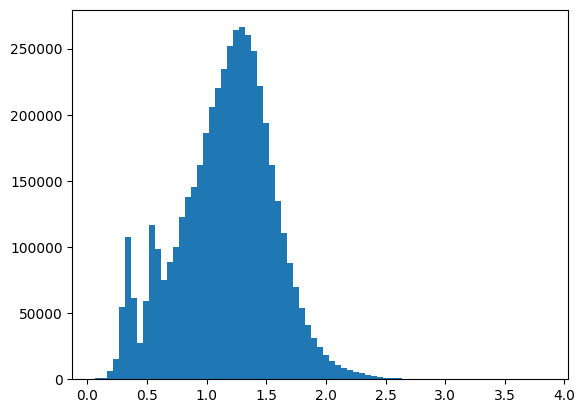

In [7]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(fit, bins=75);